In [ ]:
import torch

print(f"torch version: {torch.__version__}")
print(f"torch cuda version: {torch.version.cuda}")
device = torch.device(torch.cuda.current_device() if torch.cuda.is_available() else "cpu")
print(f"torch device: {device}")
print(f"device name: {torch.cuda.get_device_name(device) if torch.cuda.is_available() else 'cpu'}")

torch version: 2.6.0+cu126
torch cuda version: 12.6
torch device: cuda:0
device name: NVIDIA GeForce RTX 4090 Laptop GPU


In [ ]:
import os

from common import SAVE_MODEL_PATH
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj"],
)

wa_save_model_path = os.path.join(SAVE_MODEL_PATH, "mistral-7b-lora-WA")
wa_merge_model = AutoModelForCausalLM.from_pretrained(
    wa_save_model_path,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
wa_tokenizer = AutoTokenizer.from_pretrained(wa_save_model_path)
wa_tokenizer.pad_token = wa_tokenizer.eos_token

In [ ]:
import re

import tqdm
from mistral_data import MissionType, MistralData

FuncFindAnswer = lambda text: re.search(r"Answer: (.*)", text).group(1).strip() if re.search(r"Answer: (.*)", text) else "None"

def predict(Model, Tokenizer, MistralData: MistralData) -> list:
    y_pred = []
    test_data = MistralData.test_dataset["train"]
    for i in tqdm.tqdm(range(len(test_data))):
        input_text = test_data["input"][i]
        instruction_text = test_data["instruction"][i]
        format_input = f"<s>[INST] {instruction_text} {input_text} [/INST]"
        input_ids = Tokenizer(format_input, return_tensors="pt").input_ids.to(
            device
        )
        attention_mask = Tokenizer(
            format_input, return_tensors="pt"
        ).attention_mask.to(device)
        Model.gradient_checkpointing_enable()
        Model.generation_config.pad_token_id = Tokenizer.pad_token_id
        output = Model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_return_sequences=1,
        )
        Model.gradient_checkpointing_enable()
        # print(sequences[0]["generated_text"])
        output_text = Tokenizer.decode(output[0], skip_special_tokens=True)
        # print(f"Output: {output_text}")
        a = FuncFindAnswer(output_text)
        # print(f"Answer: {a}")
        y_pred.append(a)
    return y_pred

y_pred = predict(wa_merge_model, wa_tokenizer, MistralData(MissionType.WA))
y_test = MistralData(MissionType.WA).df_test["y_true"].tolist()

print(f"y_test: {y_test}")
print(f"y_pred: {y_pred}")

2025-04-20 13:16:10 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows


MISC_DATA_PATH: ..\..\MISC
JOB_DATA_PATH: ..\..\MISC\job_data_files


Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 49462.31it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-20 13:16:11 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows
Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 99149.02it/s]


...

100%|██████████| 99/99 [00:56<00:00,  1.75it/s]
2025-04-20 13:17:08 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows
Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 49379.96it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-20 13:17:09 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows
Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 49509.49it/s]


Generating train split: 0 examples [00:00, ? examples/s]

y_test: ['OnSite', 'OnSite', 'Remote', 'Hybrid', 'Remote', 'OnSite', 'Hybrid', 'Remote', 'Hybrid', 'Remote', 'Hybrid', 'OnSite', 'Remote', 'OnSite', 'OnSite', 'OnSite', 'OnSite', 'Remote', 'OnSite', 'Remote', 'Remote', 'Hybrid', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'Remote', 'OnSite', 'OnSite', 'Hybrid', 'Hybrid', 'Remote', 'OnSite', 'OnSite', 'OnSite', 'Hybrid', 'Hybrid', 'OnSite', 'Hybrid', 'Remote', 'Remote', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'Remote', 'Remote', 'OnSite', 'Hybrid', 'Hybrid', 'OnSite', 'OnSite', 'OnSite', 'Remote', 'OnSite', 'Hybrid', 'Hybrid', 'Remote', 'OnSite', 'Hybrid', 'OnSite', 'Hybrid', 'Remote', 'Remote', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'Remote', 'OnSite', 'Remote', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'Hybrid', 'OnSite', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'OnSite', 'Hybrid', 'Remote', 'OnSite', 'OnSite', 'Remote', 'OnSite', 'Hybrid', 'OnSite', 'OnSite', 'OnSite']
y

In [ ]:
import pandas as pd

df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred})
# read csv file
# df = pd.read_csv("./WA_Mistral_7B_Lora.csv")
# df.to_csv("WA_Mistral_7B_Lora.csv", index=False)
df.head()
y_pred = df["y_pred"].tolist()
y_test = df["y_true"].tolist()

Accuracy: 	 0.84848485
Precision: 	 0.84848485
Recall: 	 0.84848485
F1 Score: 	 0.84848485
Classification Report: 
              precision    recall  f1-score   support

      Hybrid       0.74      0.74      0.74        27
      OnSite       0.89      0.89      0.89        46
      Remote       0.88      0.88      0.88        26

    accuracy                           0.85        99
   macro avg       0.84      0.84      0.84        99
weighted avg       0.85      0.85      0.85        99

Labels: ['Remote', 'OnSite', 'Hybrid']


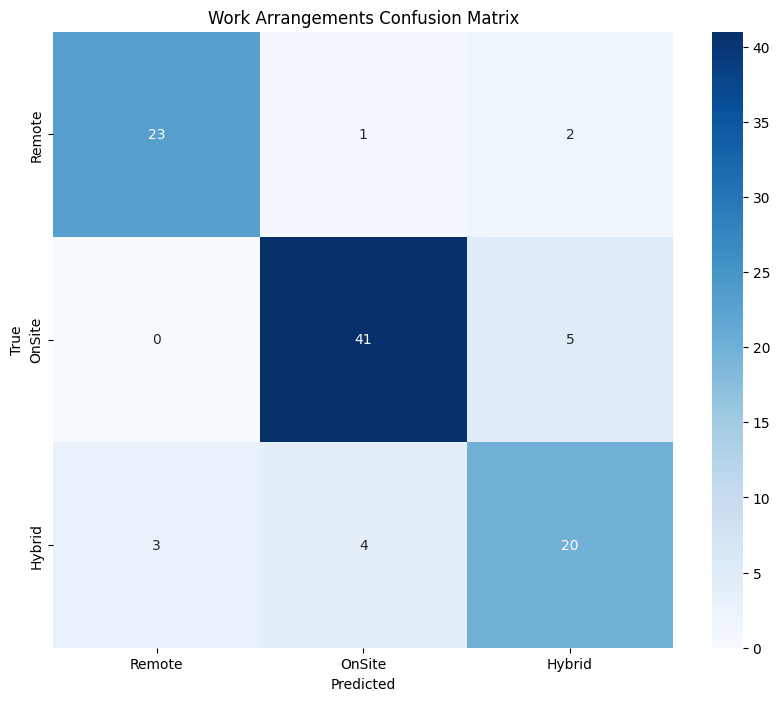

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: \t {accuracy:.8f}")
# Calculate precision

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
print(f"Precision: \t {precision:.8f}")

# Calculate recall
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Recall: \t {recall:.8f}")

# Calculate F1 score
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
print(f"F1 Score: \t {f1:.8f}")

# # Generate classification report
report = classification_report(y_test, y_pred, zero_division=0)
print(f"Classification Report: \n{report}")

import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
from sklearn.metrics import confusion_matrix

# labels = distinct(y_test + y_pred)
labels = list(set(y_test + y_pred))
print(f"Labels: {labels}")
confusion = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Work Arrangements Confusion Matrix")
plt.show()